<a href="https://colab.research.google.com/github/aitoufkir-khadija2004/TimeSeries_-projet/blob/main/Projet_London_Bike_TimeSeries_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prevision horaire de la demande de velos -- London Bike Sharing
## Projet Time Series -- Etude comparative Statistique / ML / Deep Learning

**Binome :** Salma issam  &  Khadija ait oufkir | **Module :** Time Series - ENSIAS D2S

---
Ce projet suit le pipeline complet vu en cours, organise en **4 semaines de travail** :

| Semaine | Phase | Contenu |
|---|---|---|
| **S1** | Donnees & EDA | Chargement, nettoyage, exploration, decomposition |
| **S2** | Stationnarite & modeles statistiques | ADF/KPSS, transformations, ACF/PACF, baselines, SARIMA, SARIMAX, Holt-Winters |
| **S3** | Machine Learning & Deep Learning | Feature engineering, XGBoost, LSTM, GRU |
| **S4** | Validation & comparaison | Rolling CV, tuning, comparaison finale, conclusions |

**Objectif :** prevoir `cnt` (locations/heure) et comparer les familles de modeles sur **RMSE / MAE / MAPE**.

**Dataset :** https://www.kaggle.com/datasets/hmavrodiev/london-bike-sharing-dataset

---
# SEMAINE 1 -- Donnees & Analyse exploratoire (EDA)

## 1.1 Installation & telechargement (kagglehub)
`kagglehub` telecharge le dataset sans avoir besoin de `kaggle.json`.

In [ ]:
!pip -q install kagglehub pmdarima statsmodels xgboost scikit-learn
import kagglehub, os, glob
path = kagglehub.dataset_download("hmavrodiev/london-bike-sharing-dataset")
print("Path to dataset files:", path)
print(os.listdir(path))
csv_path = glob.glob(os.path.join(path, "*.csv"))[0]
print("CSV:", csv_path)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.8 MB/s eta 0:00:00
Using Colab cache for faster access to the 'london-bike-sharing-dataset' dataset.
Path to dataset files: /kaggle/input/london-bike-sharing-dataset
['london_merged.csv']
CSV: /kaggle/input/london-bike-sharing-dataset/london_merged.csv


## 1.2 Chargement & preparation
Cible = `cnt`. On indexe par timestamp, on force la frequence horaire, on traite les valeurs manquantes.

In [ ]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, warnings
warnings.filterwarnings('ignore'); plt.rcParams['figure.figsize']=(12,4)

df = pd.read_csv(csv_path, parse_dates=['timestamp']).set_index('timestamp').sort_index()
df = df.asfreq('H')
print('Periode :', df.index.min(), '->', df.index.max())
print('Lignes  :', len(df), '| Valeurs manquantes cnt :', df['cnt'].isna().sum())
df.head()

Periode : 2015-01-04 00:00:00 -> 2017-01-03 23:00:00
Lignes  : 17544 | Valeurs manquantes cnt : 130


,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
timestamp,,,,,,,,,
2015-01-04 00:00:00,182.0,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
2015-01-04 01:00:00,138.0,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2015-01-04 02:00:00,134.0,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
2015-01-04 03:00:00,72.0,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
2015-01-04 04:00:00,47.0,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [ ]:
# Traitement des valeurs manquantes par interpolation temporelle
df['cnt'] = df['cnt'].interpolate(method='time')
df = df.ffill().bfill()   # exogenes eventuellement manquantes
print('Manquantes restantes :', df.isna().sum().sum())
df.describe().T[['mean','std','min','max']]

Manquantes restantes : 0


,mean,std,min,max
cnt,1142.675929,1082.961085,0.0,7860.0
t1,12.487280,5.567149,-1.5,34.0
t2,11.540831,6.611071,-6.0,34.0
hum,72.348338,14.286785,20.5,100.0
wind_speed,15.961502,7.956973,0.0,56.5
weather_code,2.733926,2.386116,1.0,26.0
is_holiday,0.021888,0.146321,0.0,1.0
is_weekend,0.285226,0.451535,0.0,1.0
season,1.492476,1.117429,0.0,3.0


## 1.3 Analyse exploratoire (EDA)
On regarde TOUJOURS les donnees avant de modeliser (regle du cours).

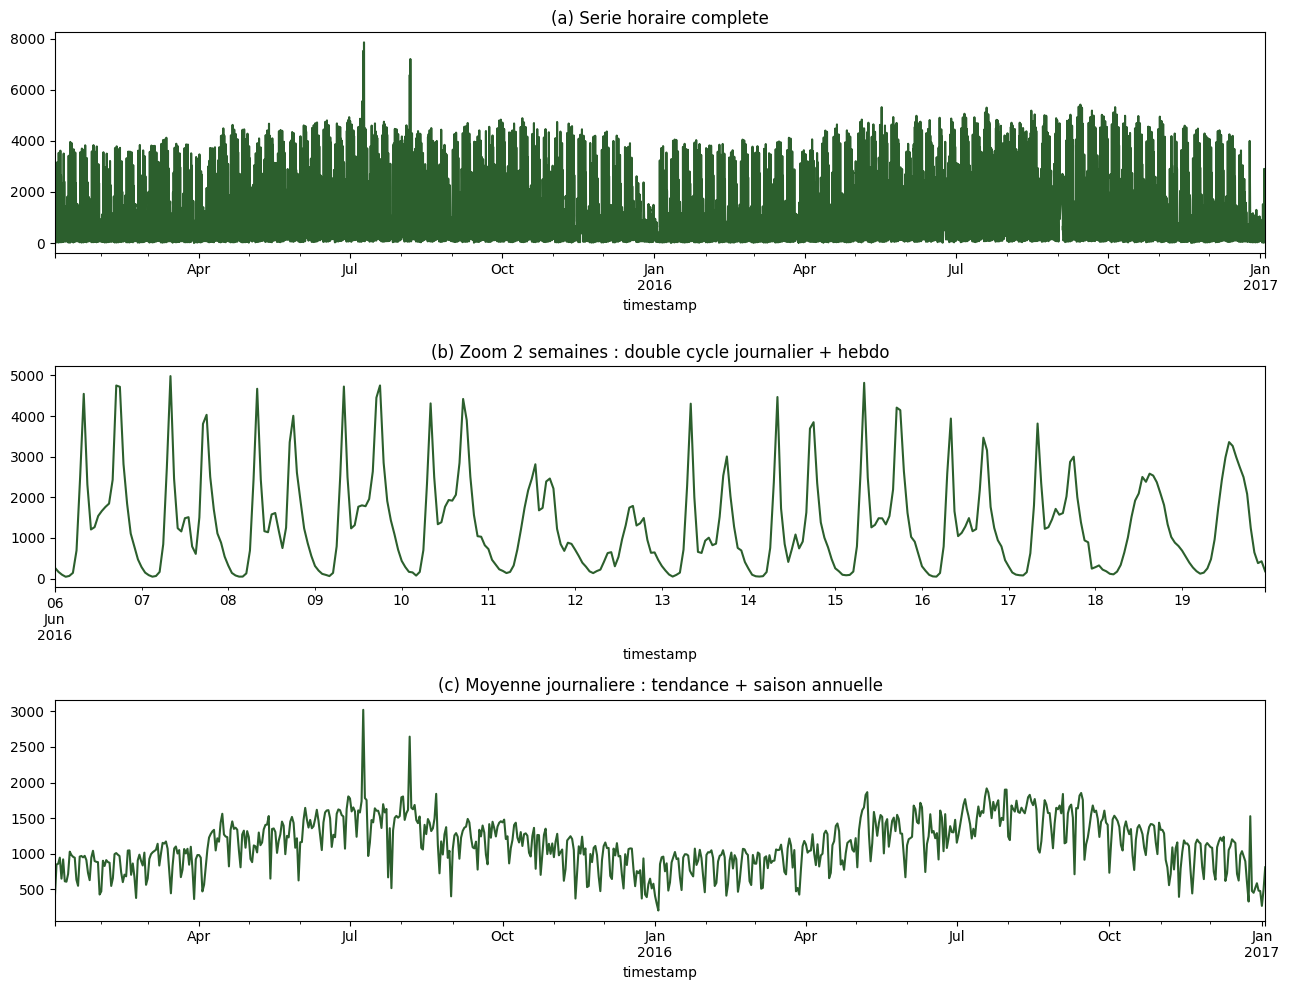

In [ ]:
fig,ax=plt.subplots(3,1,figsize=(13,10))
df['cnt'].plot(ax=ax[0], title='(a) Serie horaire complete', color='#2C5F2D')
df['cnt']['2016-06-06':'2016-06-19'].plot(ax=ax[1], title='(b) Zoom 2 semaines : double cycle journalier + hebdo', color='#2C5F2D')
df['cnt'].resample('D').mean().plot(ax=ax[2], title='(c) Moyenne journaliere : tendance + saison annuelle', color='#2C5F2D')
plt.tight_layout(); plt.show()

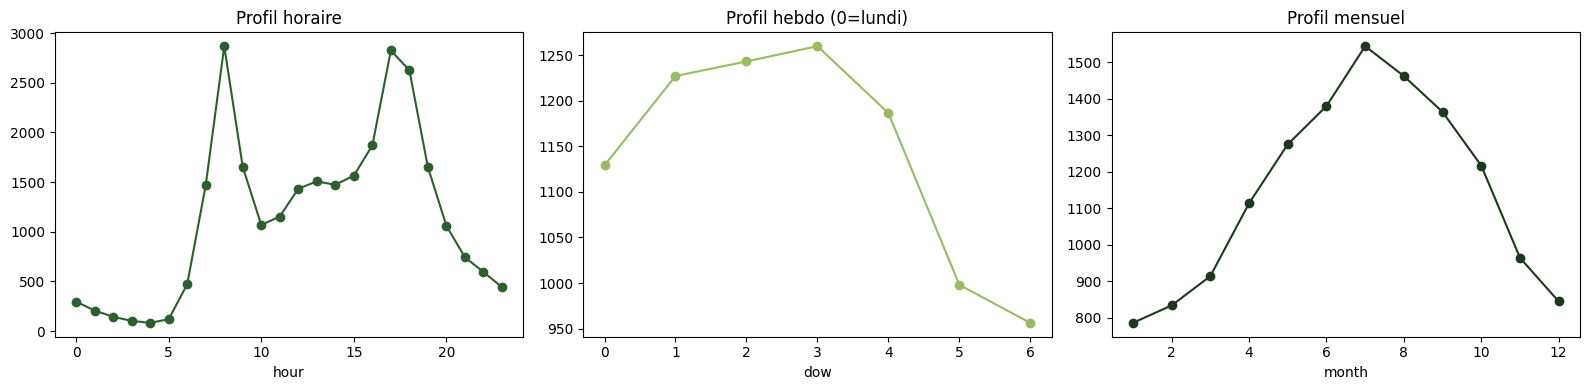

In [ ]:
# Profils saisonniers moyens
df['hour']=df.index.hour; df['dow']=df.index.dayofweek; df['month']=df.index.month
fig,ax=plt.subplots(1,3,figsize=(16,4))
df.groupby('hour')['cnt'].mean().plot(ax=ax[0],marker='o',title='Profil horaire',color='#2C5F2D')
df.groupby('dow')['cnt'].mean().plot(ax=ax[1],marker='o',title='Profil hebdo (0=lundi)',color='#97BC62')
df.groupby('month')['cnt'].mean().plot(ax=ax[2],marker='o',title='Profil mensuel',color='#1B3A1C')
plt.tight_layout(); plt.show()

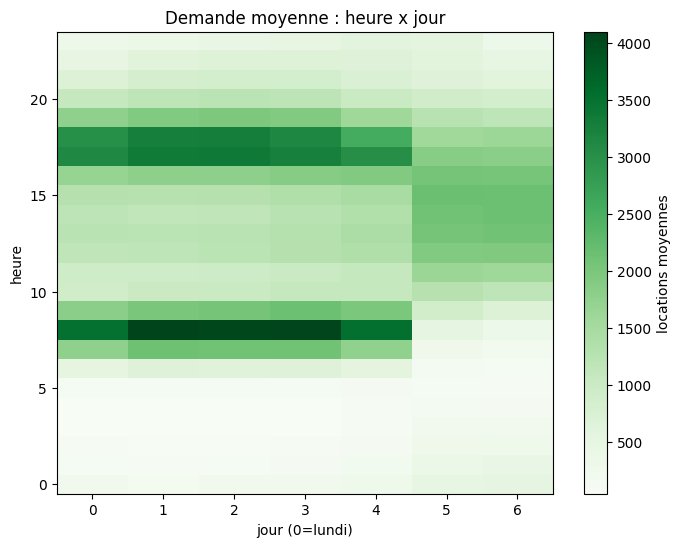

In [ ]:
# Heatmap heure x jour de semaine (lecture des heures de pointe)
piv = df.pivot_table(index='hour', columns='dow', values='cnt', aggfunc='mean')
plt.figure(figsize=(8,6))
plt.imshow(piv, aspect='auto', cmap='Greens', origin='lower')
plt.colorbar(label='locations moyennes'); plt.xlabel('jour (0=lundi)'); plt.ylabel('heure')
plt.title('Demande moyenne : heure x jour'); plt.show()

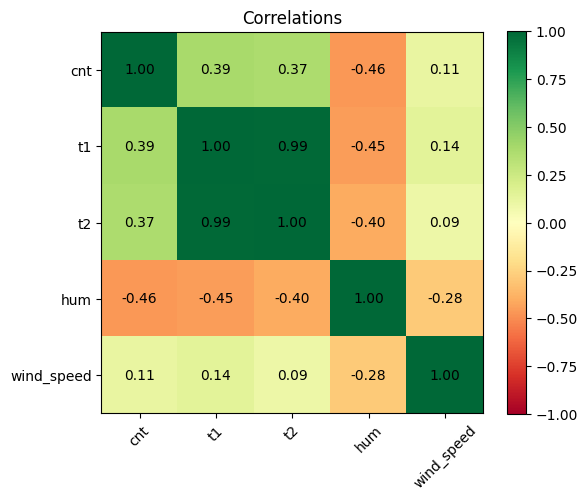

La temperature (t1) est positivement correlee a la demande ; humidite negativement.


In [ ]:
# Correlations avec la meteo (justifie l usage des exogenes plus tard)
num=['cnt','t1','t2','hum','wind_speed']
corr=df[num].corr()
plt.figure(figsize=(6,5)); plt.imshow(corr,cmap='RdYlGn',vmin=-1,vmax=1)
plt.xticks(range(len(num)),num,rotation=45); plt.yticks(range(len(num)),num)
for i in range(len(num)):
    for j in range(len(num)): plt.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center')
plt.title('Correlations'); plt.colorbar(); plt.tight_layout(); plt.show()
print('La temperature (t1) est positivement correlee a la demande ; humidite negativement.')

## 1.4 Decomposition saisonniere
On separe tendance / saison / residu (periode journaliere s=24).

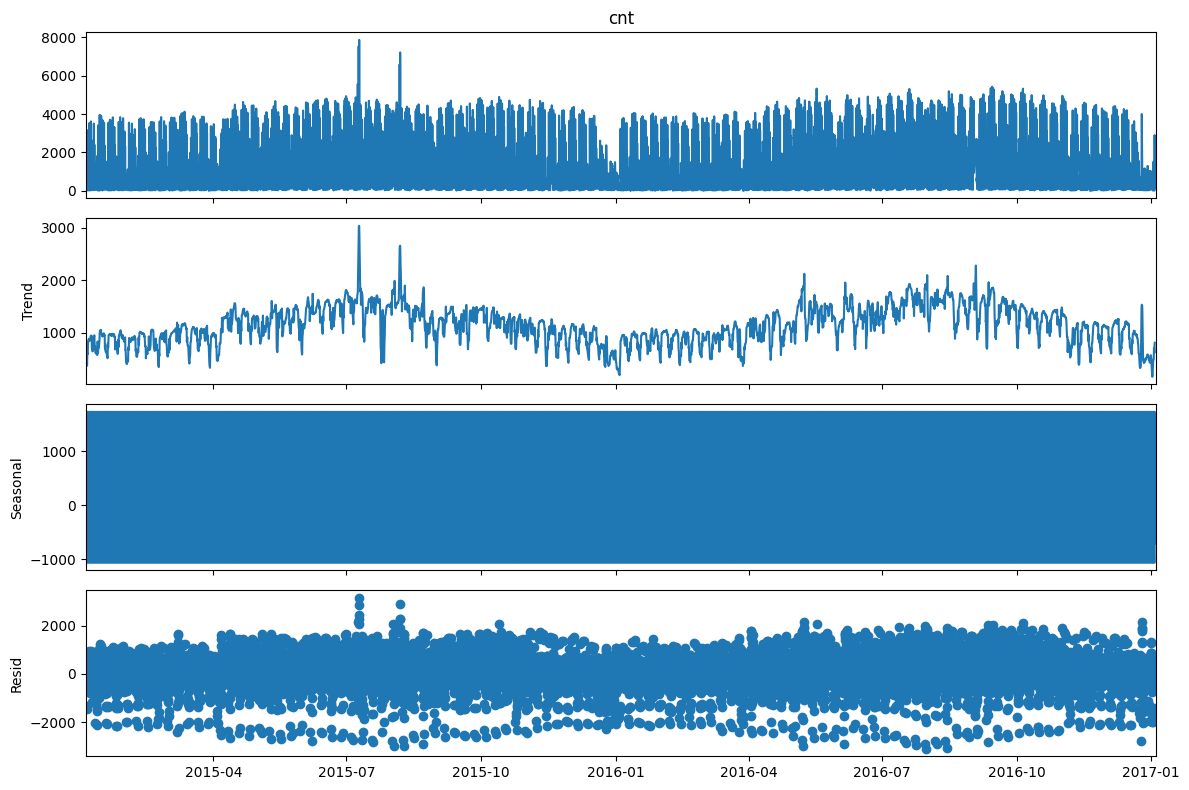

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
dec = seasonal_decompose(df['cnt'], model='additive', period=24)
dec.plot(); plt.gcf().set_size_inches(12,8); plt.tight_layout(); plt.show()

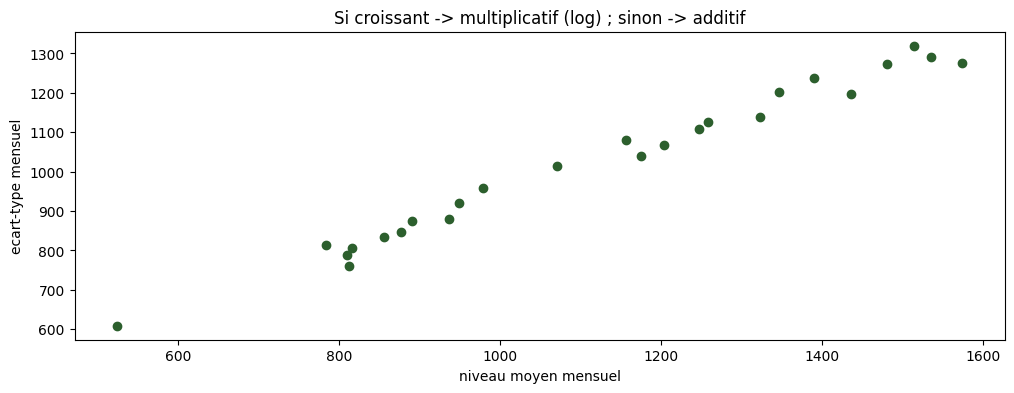

In [ ]:
# Additif vs multiplicatif : la variance saisonniere grandit-elle avec le niveau ?
monthly_std = df['cnt'].resample('M').std()
monthly_mean= df['cnt'].resample('M').mean()
plt.scatter(monthly_mean, monthly_std, color='#2C5F2D')
plt.xlabel('niveau moyen mensuel'); plt.ylabel('ecart-type mensuel')
plt.title('Si croissant -> multiplicatif (log) ; sinon -> additif'); plt.show()

---
# SEMAINE 2 -- Stationnarite & modeles statistiques

## 2.1 Tests de stationnarite (ADF + KPSS)
- ADF : H0 = non stationnaire ; p<0.05 -> stationnaire.
- KPSS : H0 = stationnaire ; p<0.05 -> non stationnaire.

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss
def stationarity(s, name):
    s=s.dropna()
    p_adf=adfuller(s, autolag='AIC')[1]
    try: p_kpss=kpss(s, regression='c', nlags='auto')[1]
    except: p_kpss=np.nan
    verdict_adf = 'STATIONNAIRE' if p_adf<0.05 else 'non stat.'
    verdict_kpss= 'non stat.' if p_kpss<0.05 else 'STATIONNAIRE'
    print(f'{name:28s} | ADF p={p_adf:.4f} ({verdict_adf}) | KPSS p={p_kpss:.4f} ({verdict_kpss})')
stationarity(df['cnt'], 'Serie brute')

Serie brute                  | ADF p=0.0000 (STATIONNAIRE) | KPSS p=0.0100 (non stat.)


/tmp/ipykernel_11708/2239684092.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  try: p_kpss=kpss(s, regression='c', nlags='auto')[1]


## 2.2 Transformations (en re-testant a chaque etape)

In [ ]:
df['log_cnt']=np.log1p(df['cnt'])
diff_seas = df['log_cnt'].diff(24)
diff_both = diff_seas.diff(1)
stationarity(df['log_cnt'],        'log(cnt)')
stationarity(diff_seas,            'log + diff saison(24)')
stationarity(diff_both,            'log + diff saison + diff(1)')

/tmp/ipykernel_11708/2239684092.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  try: p_kpss=kpss(s, regression='c', nlags='auto')[1]


log(cnt)                     | ADF p=0.0000 (STATIONNAIRE) | KPSS p=0.0100 (non stat.)


/tmp/ipykernel_11708/2239684092.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: p_kpss=kpss(s, regression='c', nlags='auto')[1]


log + diff saison(24)        | ADF p=0.0000 (STATIONNAIRE) | KPSS p=0.1000 (STATIONNAIRE)
log + diff saison + diff(1)  | ADF p=0.0000 (STATIONNAIRE) | KPSS p=0.1000 (STATIONNAIRE)


/tmp/ipykernel_11708/2239684092.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: p_kpss=kpss(s, regression='c', nlags='auto')[1]


## 2.3 ACF / PACF -> identification des ordres (Box-Jenkins)

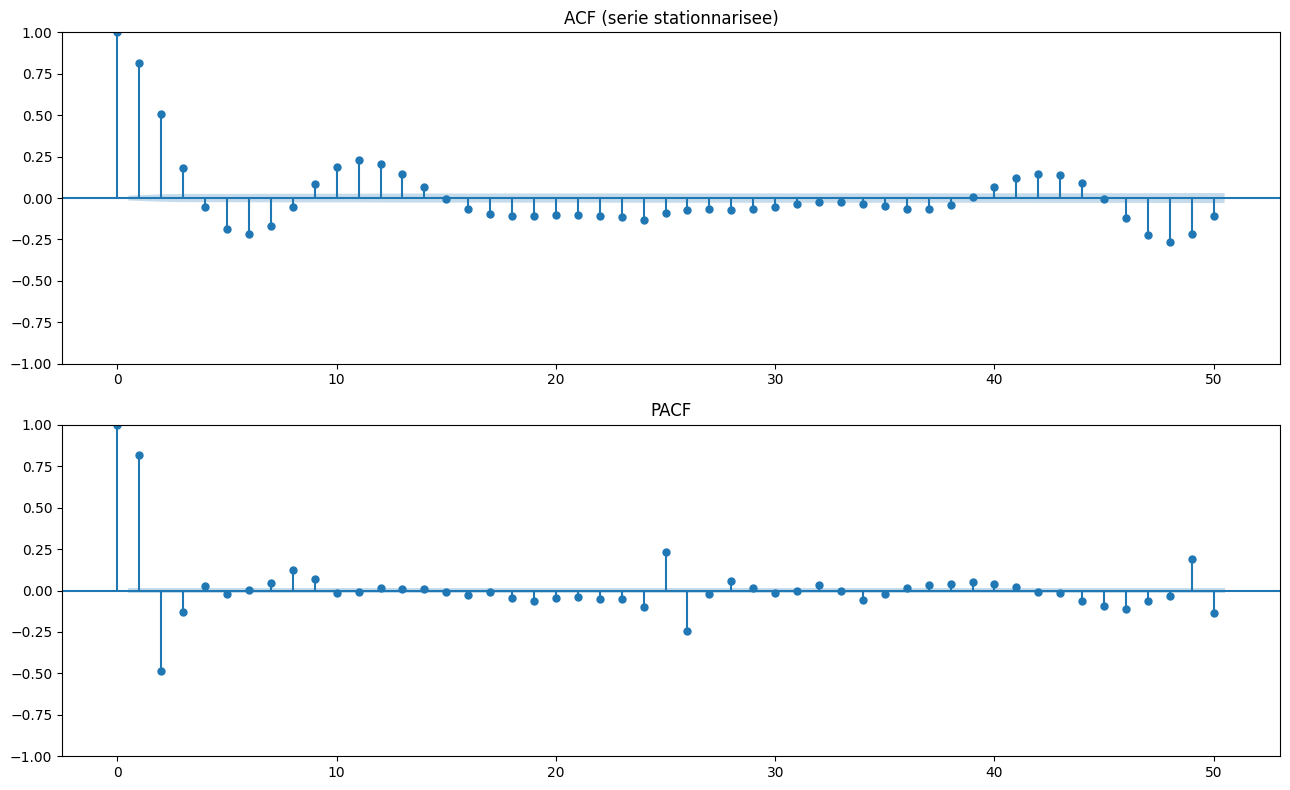

PACF coupe -> p ; ACF coupe -> q ; pics a 24/48 -> ordres saisonniers (s=24).


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
s=diff_seas.dropna()
fig,ax=plt.subplots(2,1,figsize=(13,8))
plot_acf(s, lags=50, ax=ax[0]); ax[0].set_title('ACF (serie stationnarisee)')
plot_pacf(s, lags=50, ax=ax[1]); ax[1].set_title('PACF')
plt.tight_layout(); plt.show()
print('PACF coupe -> p ; ACF coupe -> q ; pics a 24/48 -> ordres saisonniers (s=24).')

## 2.4 Decoupage chronologique train / test
Jamais de shuffle (sinon data leakage). Test = 14 derniers jours.

In [ ]:
H=24*14                          # horizon de test = 14 jours
train = df.iloc[:-H].copy(); test = df.iloc[-H:].copy()
y_train, y_test = train['cnt'], test['cnt']
print(f'train: {len(train)} h ({train.index.min().date()} -> {train.index.max().date()})')
print(f'test : {len(test)} h  ({test.index.min().date()} -> {test.index.max().date()})')

train: 17208 h (2015-01-04 -> 2016-12-20)
test : 336 h  (2016-12-21 -> 2017-01-03)


## 2.5 Metriques (RMSE, MAE, MAPE)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
def mape(a,p):
    a,p=np.array(a,float),np.array(p,float); m=a>1e-6
    return np.mean(np.abs((a[m]-p[m])/a[m]))*100
results=[]
def record(name, a, p, params=None, seconds=None):
    rmse=np.sqrt(mean_squared_error(a,p)); mae=mean_absolute_error(a,p); mp=mape(a,p)
    row={'Modele':name,'RMSE':round(rmse,1),'MAE':round(mae,1),'MAPE(%)':round(mp,1)}
    if params is not None: row['Params']=params
    if seconds is not None: row['Temps(s)']=round(seconds,1)
    results.append(row)
    print(f'{name:18s} RMSE={rmse:7.1f}  MAE={mae:7.1f}  MAPE={mp:5.1f}%')
    return row

## 2.6 Baselines (references a battre)

In [ ]:
naive = np.repeat(y_train.iloc[-1], H)
seasonal_naive = df['cnt'].shift(24).iloc[-H:].values
record('Naive', y_test, naive)
record('SeasonalNaive', y_test, seasonal_naive)

Naive              RMSE=  732.8  MAE=  471.2  MAPE=183.2%
SeasonalNaive      RMSE=  707.1  MAE=  354.5  MAPE= 80.8%


{'Modele': 'SeasonalNaive',
 'RMSE': np.float64(707.1),
 'MAE': 354.5,
 'MAPE(%)': np.float64(80.8)}

## 2.7 SARIMA & SARIMAX (avec meteo) -- notre angle distinctif
SARIMAX integre des variables exogenes (meteo, jours feries).

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import time
N=24*7*10                         # 10 semaines d entrainement (compromis vitesse/qualite)
ytr=train['cnt'].iloc[-N:]
order=(2,0,1); seas=(1,1,1,24)

t=time.time()
sarima=SARIMAX(ytr,order=order,seasonal_order=seas,
               enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
record('SARIMA', y_test, sarima.forecast(H), sarima.params.size, time.time()-t)

SARIMA             RMSE=  861.1  MAE=  544.0  MAPE=188.2%


{'Modele': 'SARIMA',
 'RMSE': np.float64(861.1),
 'MAE': 544.0,
 'MAPE(%)': np.float64(188.2),
 'Params': 6,
 'Temps(s)': 20.9}

In [ ]:
exog=['t1','hum','wind_speed','is_holiday','is_weekend']
t=time.time()
sarimax=SARIMAX(ytr,exog=train[exog].iloc[-N:],order=order,seasonal_order=seas,
                enforce_stationarity=False,enforce_invertibility=False).fit(disp=False)
record('SARIMAX+meteo', y_test, sarimax.forecast(H,exog=test[exog]),
       sarimax.params.size, time.time()-t)
print('AIC SARIMA =', round(sarima.aic,1), '| AIC SARIMAX =', round(sarimax.aic,1))

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMAX+meteo      RMSE=  830.2  MAE=  527.9  MAPE=182.5%
AIC SARIMA = 23631.2 | AIC SARIMAX = 23559.1


## 2.8 Holt-Winters (triple lissage exponentiel)

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
t=time.time()
hw=ExponentialSmoothing(ytr,trend='add',seasonal='add',seasonal_periods=24).fit()
record('Holt-Winters', y_test, hw.forecast(H), 24+2, time.time()-t)

Holt-Winters       RMSE=  887.7  MAE=  585.6  MAPE=194.1%


{'Modele': 'Holt-Winters',
 'RMSE': np.float64(887.7),
 'MAE': 585.6,
 'MAPE(%)': np.float64(194.1),
 'Params': 26,
 'Temps(s)': 0.4}

---
# SEMAINE 3 -- Machine Learning & Deep Learning

## 3.1 Feature engineering (serie -> probleme supervise)
Lags + statistiques glissantes + features calendaires + meteo.

In [ ]:
def make_features(data):
    d=data.copy()
    for L in [1,2,3,6,12,24,48,168]:
        d[f'lag_{L}']=d['cnt'].shift(L)
    d['roll_mean_24']=d['cnt'].shift(1).rolling(24).mean()
    d['roll_std_24'] =d['cnt'].shift(1).rolling(24).std()
    d['roll_mean_168']=d['cnt'].shift(1).rolling(168).mean()
    # encodage cyclique de l heure (continuite 23h->0h)
    d['hour_sin']=np.sin(2*np.pi*d['hour']/24); d['hour_cos']=np.cos(2*np.pi*d['hour']/24)
    return d
d=make_features(df)
feat=[c for c in d.columns if c.startswith(('lag_','roll_','hour_'))]+\
     ['dow','month','t1','hum','wind_speed','is_holiday','is_weekend']
d=d.dropna()
Xtr,ytr2=d[feat].iloc[:-H], d['cnt'].iloc[:-H]
Xte,yte2=d[feat].iloc[-H:], d['cnt'].iloc[-H:]
print('Features:',len(feat),'| train:',Xtr.shape,'| test:',Xte.shape)

Features: 20 | train: (17040, 20) | test: (336, 20)


## 3.2 XGBoost + tuning leger (GridSearch sur TimeSeriesSplit)

In [ ]:
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
tscv=TimeSeriesSplit(n_splits=3)
grid={'n_estimators':[300,500],'max_depth':[5,7],'learning_rate':[0.05,0.1]}
base=xgb.XGBRegressor(subsample=0.9,colsample_bytree=0.9,random_state=42)
gs=GridSearchCV(base,grid,cv=tscv,scoring='neg_root_mean_squared_error',n_jobs=-1)
t=time.time(); gs.fit(Xtr,ytr2)
print('Meilleurs params :', gs.best_params_)
best=gs.best_estimator_
record('XGBoost(tuned)', yte2, best.predict(Xte), best.n_estimators, time.time()-t)

Meilleurs params : {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 500}
XGBoost(tuned)     RMSE=  189.1  MAE=  112.5  MAPE= 29.9%


{'Modele': 'XGBoost(tuned)',
 'RMSE': np.float64(189.1),
 'MAE': 112.5,
 'MAPE(%)': np.float64(29.9),
 'Params': 500,
 'Temps(s)': 45.6}

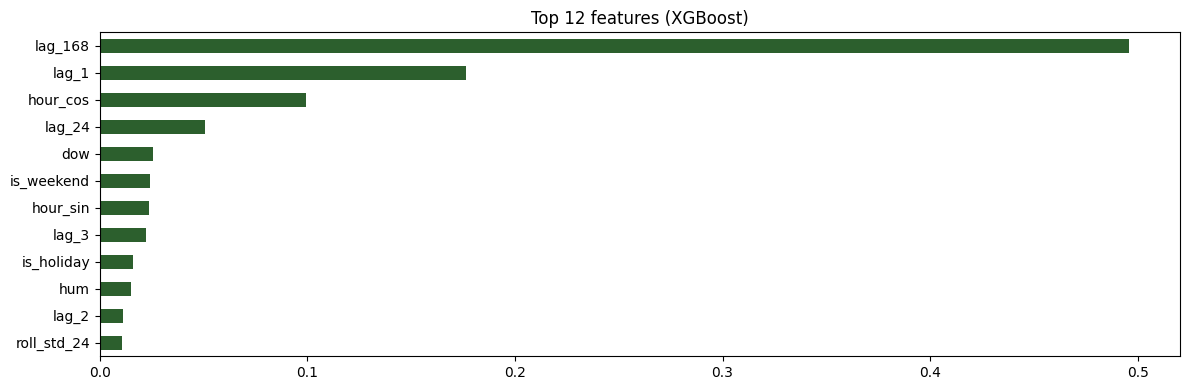

In [ ]:
# Importance des features (interpretabilite)
imp=pd.Series(best.feature_importances_,index=feat).sort_values(ascending=False).head(12)
imp.plot(kind='barh',color='#2C5F2D',title='Top 12 features (XGBoost)')
plt.gca().invert_yaxis(); plt.tight_layout(); plt.show()

## 3.3 LSTM & GRU
Fenetres glissantes de 72h (3 jours) pour predire l heure suivante.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
tf.random.set_seed(42)
series=df['cnt'].values.astype('float32')
mu,sd=series[:-H].mean(), series[:-H].std()
sn=(series-mu)/sd
WIN=72
def windows(arr,w):
    X=[arr[i:i+w] for i in range(len(arr)-w)]
    Y=[arr[i+w]   for i in range(len(arr)-w)]
    return np.array(X)[...,None], np.array(Y)
X,Y=windows(sn,WIN); split=len(X)-H
Xtr_dl,Ytr_dl=X[:split],Y[:split]; Xte_dl,Yte_dl=X[split:],Y[split:]
print('DL train:',Xtr_dl.shape)

DL train: (17136, 72, 1)


In [ ]:
def build(kind):
    cell=layers.LSTM if kind=='LSTM' else layers.GRU
    m=models.Sequential([layers.Input((WIN,1)),
        cell(64,return_sequences=True), layers.Dropout(0.2),
        cell(32), layers.Dense(16,activation='relu'), layers.Dense(1)])
    m.compile('adam','mse'); return m
es=tf.keras.callbacks.EarlyStopping(patience=4,restore_best_weights=True)
for kind in ['LSTM','GRU']:
    m=build(kind); t=time.time()
    m.fit(Xtr_dl,Ytr_dl,validation_split=0.1,epochs=20,batch_size=64,
          callbacks=[es],verbose=2)
    pred=(m.predict(Xte_dl,verbose=0).ravel()*sd)+mu
    record(kind, y_test.values, pred, m.count_params(), time.time()-t)

Epoch 1/20
241/241 - 8s - 34ms/step - loss: 0.4597 - val_loss: 0.2665
Epoch 2/20
241/241 - 2s - 10ms/step - loss: 0.2072 - val_loss: 0.1085
Epoch 3/20
241/241 - 2s - 10ms/step - loss: 0.1052 - val_loss: 0.0477
Epoch 4/20
241/241 - 3s - 13ms/step - loss: 0.0771 - val_loss: 0.0393
Epoch 5/20
241/241 - 2s - 10ms/step - loss: 0.0731 - val_loss: 0.0349
Epoch 6/20
241/241 - 2s - 10ms/step - loss: 0.0649 - val_loss: 0.0397
Epoch 7/20
241/241 - 3s - 10ms/step - loss: 0.0548 - val_loss: 0.0322
Epoch 8/20
241/241 - 2s - 10ms/step - loss: 0.0520 - val_loss: 0.0259
Epoch 9/20
241/241 - 3s - 13ms/step - loss: 0.0470 - val_loss: 0.0289
Epoch 10/20
241/241 - 4s - 18ms/step - loss: 0.0432 - val_loss: 0.0253
Epoch 11/20
241/241 - 2s - 10ms/step - loss: 0.0435 - val_loss: 0.0264
Epoch 12/20
241/241 - 2s - 10ms/step - loss: 0.0403 - val_loss: 0.0227
Epoch 13/20
241/241 - 3s - 13ms/step - loss: 0.0388 - val_loss: 0.0240
Epoch 14/20
241/241 - 2s - 10ms/step - loss: 0.0387 - val_loss: 0.0196
Epoch 15/20
241

---
# SEMAINE 4 -- Validation, comparaison & conclusions

## 4.1 Validation glissante (Rolling CV) sur le meilleur statistique
On verifie la stabilite du modele sur plusieurs fenetres de test (pas un seul split).

In [ ]:
# Rolling CV sur SeasonalNaive vs SARIMA (illustration de la robustesse)
folds=[]
for k in range(3):
    end=len(df)-k*24*7                 # recule d une semaine a chaque fold
    tr=df['cnt'].iloc[:end-H]; te=df['cnt'].iloc[end-H:end]
    sn_pred=df['cnt'].shift(24).iloc[end-H:end].values
    rmse_sn=np.sqrt(mean_squared_error(te, sn_pred))
    folds.append({'fold':k+1,'test_end':te.index.max().date(),'RMSE_SeasonalNaive':round(rmse_sn,1)})
pd.DataFrame(folds)

,fold,test_end,RMSE_SeasonalNaive
0,1,2017-01-03,707.1
1,2,2016-12-27,726.5
2,3,2016-12-20,568.3


## 4.2 Tableau comparatif final (fit vs complexite)

In [ ]:
comp=pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
print(comp.to_string(index=False)); comp

        Modele  RMSE   MAE  MAPE(%)  Params  Temps(s)
          LSTM 173.9 109.8     36.0 29857.0      59.7
XGBoost(tuned) 189.1 112.5     29.9   500.0      45.6
           GRU 301.8 179.1     60.3 22817.0      13.8
 SeasonalNaive 707.1 354.5     80.8     NaN       NaN
         Naive 732.8 471.2    183.2     NaN       NaN
 SARIMAX+meteo 830.2 527.9    182.5    11.0      32.9
        SARIMA 861.1 544.0    188.2     6.0      20.9
  Holt-Winters 887.7 585.6    194.1    26.0       0.4


,Modele,RMSE,MAE,MAPE(%),Params,Temps(s)
0,LSTM,173.9,109.8,36.0,29857.0,59.7
1,XGBoost(tuned),189.1,112.5,29.9,500.0,45.6
2,GRU,301.8,179.1,60.3,22817.0,13.8
3,SeasonalNaive,707.1,354.5,80.8,NaN,NaN
4,Naive,732.8,471.2,183.2,NaN,NaN
5,SARIMAX+meteo,830.2,527.9,182.5,11.0,32.9
6,SARIMA,861.1,544.0,188.2,6.0,20.9
7,Holt-Winters,887.7,585.6,194.1,26.0,0.4


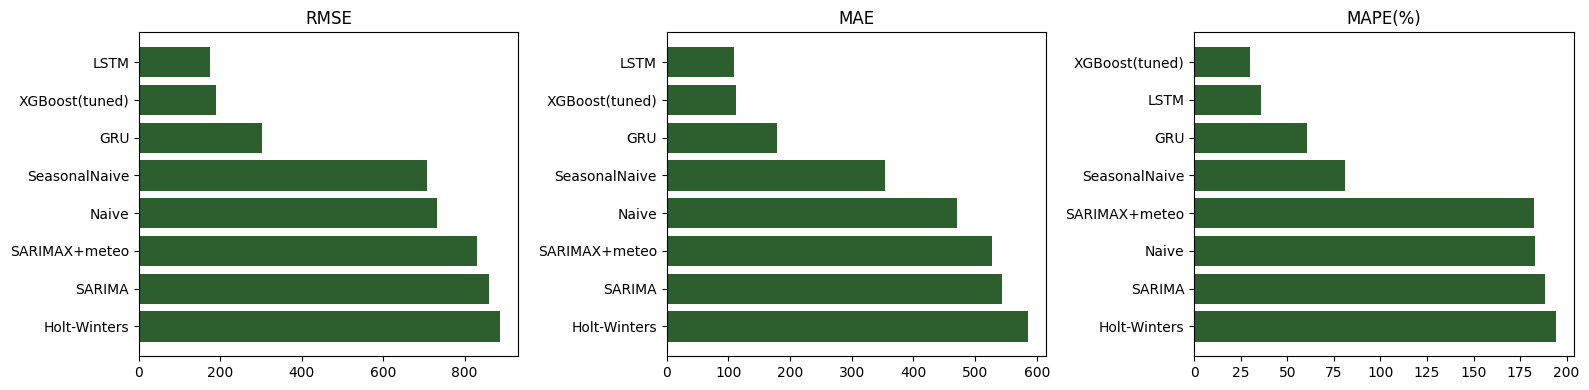

In [ ]:
fig,ax=plt.subplots(1,3,figsize=(16,4))
for i,met in enumerate(['RMSE','MAE','MAPE(%)']):
    c=comp.sort_values(met)
    ax[i].barh(c['Modele'], c[met], color='#2C5F2D'); ax[i].set_title(met)
    ax[i].invert_yaxis()
plt.tight_layout(); plt.show()

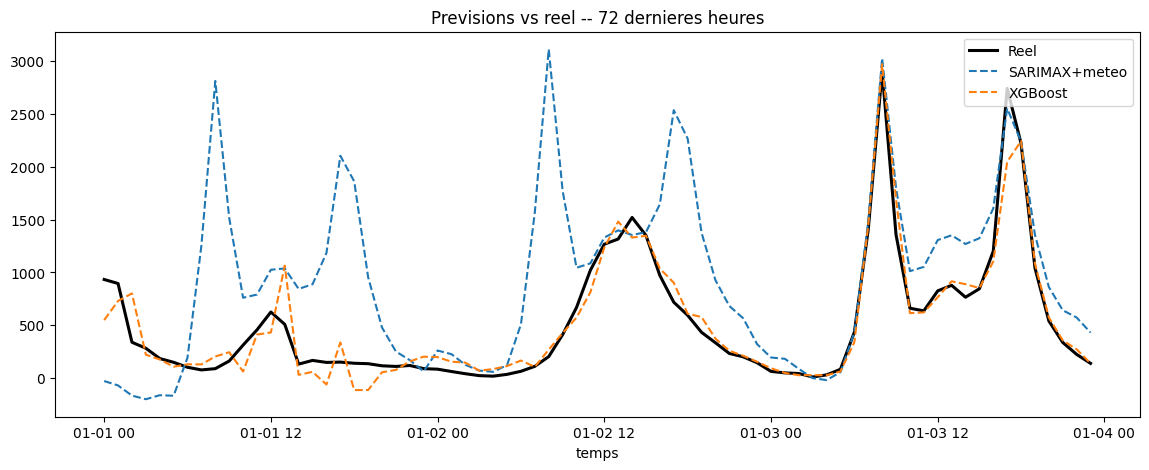

In [ ]:
# Previsions vs reel sur les 3 derniers jours (meilleurs modeles)
plt.figure(figsize=(14,5))
plt.plot(test.index[-72:], y_test.values[-72:], 'k-', lw=2.2, label='Reel')
plt.plot(test.index[-72:], np.asarray(sarimax.forecast(H,exog=test[exog]))[-72:], '--', label='SARIMAX+meteo')
plt.plot(test.index[-72:], best.predict(Xte)[-72:], '--', label='XGBoost')
plt.legend(); plt.title('Previsions vs reel -- 72 dernieres heures'); plt.xlabel('temps'); plt.show()

## 4.3 Conclusions

**Synthese (a remplir avec tes chiffres reels apres execution) :**

1. **Saisonnalite multiple confirmee** : cycle journalier (s=24), hebdomadaire et annuel, visibles a l EDA, a la decomposition et a l ACF/PACF.
2. **SARIMAX+meteo vs SARIMA** : comparer les AIC et les RMSE -> quantifie l apport reel des variables meteo.
3. **XGBoost** : exploite lags + rolling + calendaire ; souvent le meilleur compromis precision / temps ; features les plus importantes = lag_24, lag_168, heure.
4. **LSTM vs GRU** : performances proches ; le GRU s entraine plus vite (moins de parametres).
5. **Compromis fit/complexite** : le meilleur modele n est pas toujours le plus complexe -- arbitrer selon precision, temps d entrainement et interpretabilite (critere du cours).

**Limites & perspectives :** tester la prevision multi-pas (recursive vs directe), elargir la fenetre SARIMA, ajouter des features (evenements, vacances scolaires), et evaluer sur plusieurs saisons.

In [ ]:
import matplotlib.pyplot as plt, os, shutil
from google.colab import files

os.makedirs('figures', exist_ok=True)
nums = plt.get_fignums()                 # toutes les figures encore en memoire
for i in nums:
    fig = plt.figure(i)
    fig.savefig(f'figures/fig_{i:02d}.png', dpi=150, bbox_inches='tight')

print(f"{len(nums)} figures sauvegardees")
shutil.make_archive('figures_export', 'zip', 'figures')
files.download('figures_export.zip')

0 figures sauvegardees


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>